In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
 95% 186M/195M [00:00<00:00, 603MB/s] 
100% 195M/195M [00:00<00:00, 613MB/s]


In [ ]:
import os
import shutil

DATASET_PATH = "/content/data/Dataset_BUSI_with_GT"
OUTPUT_PATH = "/content/data/Dataset_BUSI_with_GT/train"

classes = ["benign", "malignant", "normal"]

os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    # Only include image files, exclude mask files
    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and "_mask" not in f.lower()
    ]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied (without masks).")

print("All class images copied into train folder (mask images removed).")

Class benign: 437 images copied (without masks).
Class malignant: 210 images copied (without masks).
Class normal: 133 images copied (without masks).
All class images copied into train folder (mask images removed).


In [ ]:
train_dir = "/content/data/Dataset_BUSI_with_GT/train"

# **Oversampling and Label Encoding**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import os

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

target_count = 450  # max images per class

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    current_count = len(images)

    if current_count >= target_count:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    needed = target_count - current_count
    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    for _ in range(needed):
        img_path = os.path.join(cls_path, images[img_index % len(images)])
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1, save_to_dir=cls_path, save_prefix="aug", save_format="jpg")
        next(aug_iter)
        img_index += 1

print("✅ Data augmentation completed.\n")

# Print final class counts
for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count} images")

Skipping benign: 450 images already present.
Skipping malignant: 450 images already present.
Skipping normal: 450 images already present.
✅ Data augmentation completed.

benign: 450 images
malignant: 450 images
normal: 450 images


In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

encoder = LabelEncoder()
df["Label_num"] = encoder.fit_transform(df["label"])

image_paths = []
labels_num = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels_num.append(encoder.transform([cls])[0])

df_balanced = pd.DataFrame({"image_path": image_paths, "label_num": labels_num})

print("Class counts after augmentation:")
print(df_balanced["label_num"].value_counts())

Class counts after augmentation:
label_num
0    450
1    450
2    450
Name: count, dtype: int64


# **Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split

df_balanced['label_num'] = df_balanced['label_num'].astype(str)

train_df, temp_df = train_test_split(df_balanced, train_size=0.8, shuffle=True,
                                     stratify=df_balanced['label_num'], random_state=42)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, shuffle=True,
                                     stratify=temp_df['label_num'], random_state=42)

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (1080, 2)
Validation size: (135, 2)
Test size: (135, 2)


# Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # ✅ use correct one

batch_size = 32
img_size = (224, 224)

# Training generator with augmentation
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validation / Test generator
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Flow from dataframe
train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label_num',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='image_path',
    y_col='label_num',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen = ts_gen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label_num',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)


Found 1080 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.


MobileNetV2 Spatial Attention

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Conv2D, Multiply, Concatenate, Layer
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# ----------------- Spatial Attention as a Custom Layer -----------------
class SpatialAttention(Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        # Conv2D created in __init__, not in call
        self.conv = Conv2D(1, kernel_size=self.kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        # Channel-wise average pooling
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        # Channel-wise max pooling
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        # Concatenate along channel axis
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        # Convolution + Sigmoid
        attention = self.conv(concat)
        # Multiply attention with input
        return inputs * attention

    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

# ----------------- MobileNetV2 + Spatial Attention -----------------
def create_mobilenetv2_spatial(input_shape=(224,224,3), num_classes=3):
    inputs = Input(shape=input_shape)

    # Pretrained MobileNetV2
    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers (fine-tune last 20)
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    # Apply Spatial Attention
    x = SpatialAttention()(x)

    # Global Pooling + Dense layers
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# ----------------- Build & Compile -----------------
model = create_mobilenetv2_spatial(num_classes=3)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------- Model Summary -----------------
model.summary()


/tmp/ipython-input-2336195602.py:40: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,048,102 (11.63 MB)

 Trainable params: 1,995,174 (7.61 MB)

 Non-trainable params: 1,052,928 (4.02 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,                  # stop if val_accuracy doesn't improve for 7 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,                  # reduce LR by 50% if plateau
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,         # save only best model
        verbose=1
    )
]

# Fit model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,                       # increase epochs; callbacks will stop early if needed
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3911 - loss: 1.1365
Epoch 1: val_accuracy improved from -inf to 0.42222, saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.3930 - loss: 1.1348 - val_accuracy: 0.4222 - val_loss: 1.0854 - learning_rate: 1.0000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5384 - loss: 0.9713
Epoch 2: val_accuracy did not improve from 0.42222
34/34 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5392 - loss: 0.9704 - val_accuracy: 0.4000 - val_loss: 1.0719 - learning_rate: 1.0000e-04
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6136 - loss: 0.8596
Epoch 3: val_accuracy improved from 0.42222 to 0.50370, saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.6145 - loss: 0.8580 - val_accuracy: 0.5037 - val_loss: 1.0357 - learning_rate: 1.0000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7331 - loss: 0.6680
Epoch 4: val_

In [ ]:
from tensorflow.keras.models import load_model

# Load the best saved model with custom_objects
best_model = load_model(
    "best_model.keras",
    custom_objects={"SpatialAttention": SpatialAttention}
)

# Evaluate on the test set
loss, accuracy = best_model.evaluate(test_gen, verbose=1)

# Print results
print(f"✅ Best Model Test Accuracy: {accuracy*100:.2f}%")
print(f"✅ Best Model Test Loss: {loss:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'spatial_attention_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7187 - loss: 1.2433
✅ Best Model Test Accuracy: 74.07%
✅ Best Model Test Loss: 1.1859


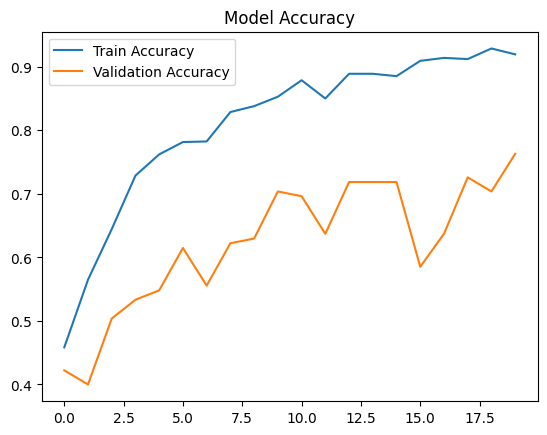

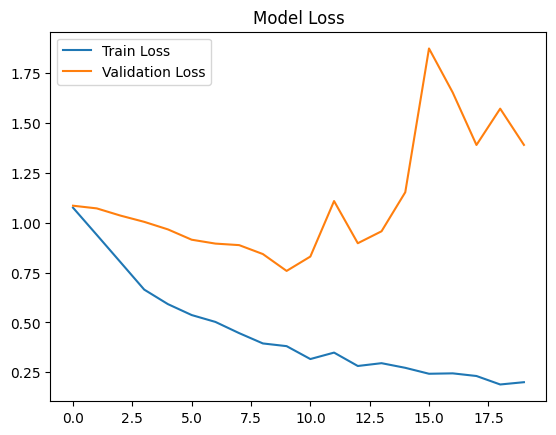

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.42      0.59        45
           1       0.80      0.80      0.80        45
           2       0.63      1.00      0.78        45

    accuracy                           0.74       135
   macro avg       0.81      0.74      0.72       135
weighted avg       0.81      0.74      0.72       135



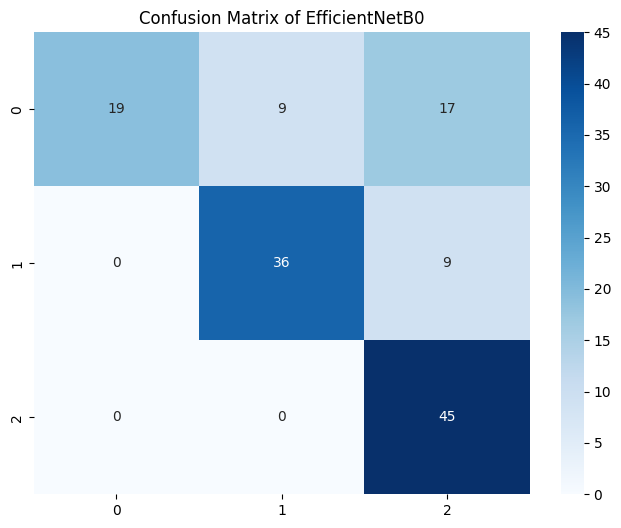

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of MobileNetV2")
plt.show()

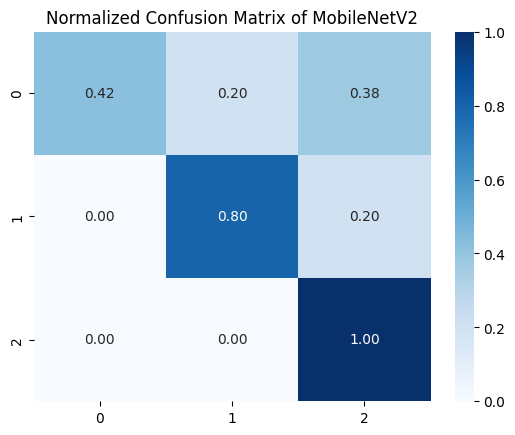

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Normalized Confusion Matrix of MobileNetV2")
plt.show()